# **MTCNN**
Credit: https://github.com/fisakhan/Face_Pose/blob/master/pose_detection_retinaface.py

In [ ]:
! pip install deepface --quiet
import cv2, polars as pl, matplotlib.pyplot as plt
import os, pickle, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace
from datasets import load_dataset
import itertools
from mtcnn.mtcnn import MTCNN
from mtcnn.utils.plotting import plot
detector = MTCNN()
#import matplotlib.pyplot as plt

In [ ]:
# @title
# https://huggingface.co/datasets/bitmind/lfw
# If using the LFW dataset
ds = load_dataset("bitmind/lfw")

# A way to find which people have at least N number of photos
N = 20
lfw_min20_photos = ds["train"].filter(lambda x: f'00{N}' in x['filename'] if N < 100 else f'0{N}' in x['filename'])

people = [i.split('0')[0] for i in lfw_min20_photos['filename']]  # just extract the names

person_images = {}
for person in people:
  person_images[person] = ds["train"].filter(lambda x: person in x["filename"])[:20] # find all matching images with that name, and cap to 20 for uniformity

os.mkdir("intra-sim")
for person in person_images.keys():
  images = ds["train"].filter(lambda x: x["filename"] in person_images[person]['filename'])
  os.mkdir(f'intra-sim/{person}')
  for i, image in enumerate(images):
    image["image"].save(f'intra-sim/{person}/{i+1}.png')

In [ ]:
# !zip -r intra-sim.zip intra-sim
!unzip intra-sim.zip

Archive:  intra-sim.zip
   creating: intra-sim/
   creating: intra-sim/Hans_Blix_/
  inflating: intra-sim/Hans_Blix_/10.png  
  inflating: intra-sim/Hans_Blix_/9.png  
  inflating: intra-sim/Hans_Blix_/8.png  
  inflating: intra-sim/Hans_Blix_/7.png  
  inflating: intra-sim/Hans_Blix_/17.png  
  inflating: intra-sim/Hans_Blix_/11.png  
  inflating: intra-sim/Hans_Blix_/3.png  
  inflating: intra-sim/Hans_Blix_/20.png  
  inflating: intra-sim/Hans_Blix_/1.png  
  inflating: intra-sim/Hans_Blix_/16.png  
  inflating: intra-sim/Hans_Blix_/15.png  
  inflating: intra-sim/Hans_Blix_/18.png  
  inflating: intra-sim/Hans_Blix_/6.png  
  inflating: intra-sim/Hans_Blix_/4.png  
  inflating: intra-sim/Hans_Blix_/2.png  
  inflating: intra-sim/Hans_Blix_/19.png  
  inflating: intra-sim/Hans_Blix_/13.png  
  inflating: intra-sim/Hans_Blix_/5.png  
  inflating: intra-sim/Hans_Blix_/14.png  
  inflating: intra-sim/Hans_Blix_/12.png  
   creating: intra-sim/Winona_Ryder_/
  inflating: intra-sim/Winon

In [ ]:
def find_pose(points):
    """
    Parameters
    ----------
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.
    Returns
    -------
    Angle
    Yaw
    Pitch
    TYPE
        pitch of face.

    """
    LMx = points[0:5]# horizontal coordinates of landmarks
    LMy = points[5:10]# vertical coordinates of landmarks

    dPx_eyes = max((LMx[1] - LMx[0]), 1)
    dPy_eyes = (LMy[1] - LMy[0])
    angle = np.arctan(dPy_eyes / dPx_eyes) # angle for rotation based on slope eyes

    alpha = np.cos(angle)
    beta = np.sin(angle)
    # rotated landmarks
    LMxr = (alpha * LMx + beta * LMy + (1 - alpha) * LMx[2] / 2 - beta * LMy[2] / 2)
    LMyr = (-beta * LMx + alpha * LMy + beta * LMx[2] / 2 + (1 - alpha) * LMy[2] / 2)

    # average distance between eyes and mouth
    dXtot = (LMxr[1] - LMxr[0] + LMxr[4] - LMxr[3]) / 2
    dYtot = (LMyr[3] - LMyr[0] + LMyr[4] - LMyr[1]) / 2

    # average distance between nose and eyes
    dXnose = (LMxr[1] - LMxr[2] + LMxr[4] - LMxr[2]) / 2
    dYnose = (LMyr[3] - LMyr[2] + LMyr[4] - LMyr[2]) / 2

    # relative rotation 0 degree is frontal 90 degree is profile
    Xfrontal = (-90+90 / 0.5 * dXnose / dXtot) if dXtot != 0 else 0
    Yfrontal = (-90+90 / 0.5 * dYnose / dYtot) if dYtot != 0 else 0

    return angle * 180 / np.pi, Xfrontal, Yfrontal

def find_roll(points):
    """
    Parameters
    ----------
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.
    Returns
    -------
    TYPE
        roll of face.

    """
    return points[5] - points[7]

def find_yaw(points):
    """
    Parameters
    ----------
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.
    Returns
    -------
    TYPE
        yaw of face.

    """
    le2n = points[0] - points[6]
    re2n = points[0] - points[4]
    return le2n - re2n

def find_pitch(points):
    """
    Parameters
    ----------
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.
    Returns
    -------
    Pitch
    """
    eye_y = (points[5] + points[7]) / 2
    mou_y = (points[3] + points[9]) / 2
    e2n = eye_y - points[1]
    n2m = points[1] - mou_y
    return e2n / n2m

In [ ]:
font = cv2.FONT_HERSHEY_SIMPLEX # Text in video
font_size = 0.4
blue = (0, 0, 255)
green = (0,128,0)
red = (255, 0, 0)

def detect_faces(image, image_shape_max=640):
    '''
    Performs face detection using retinaface method with speed boost and initial quality checks based on whole image size

    Parameters
    ----------
    image : uint8
        image for face detection.
    image_shape_max : int, optional
        maximum size (in pixels) of image. The default is None.

    Returns
    -------
    float array
        bounding boxes and score.
    float array
        landmarks.
    '''

    image_shape = image.shape[:2]

    # perform image resize for faster detection
    if image_shape_max:
        scale_factor = max([1, max(image_shape) / image_shape_max])
    else:
        scale_factor = 1

    if scale_factor > 1:
        scaled_image = cv2.resize(image, (0, 0), fx = 1/scale_factor, fy = 1/scale_factor)
        bbs, points = detector.detect_faces(scaled_image)
        bbs[:,:4] *= scale_factor
        points *= scale_factor
    else:
        bbs, points = detector.detect_faces(image)

    return bbs, points

def draw_landmarks(frame, bb, points):
    '''
    Parameters
    ----------
    frame : TYPE
        RGB image
    bb : TYPE - Array of float64, Size = (5,)
        coordinates of bounding box for the selected face.
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.

    Returns
    -------
    None.

    '''
    bb = bb.astype(int)
    points = points.astype(int)
    # draw rectangle and landmarks on face
    #cv2.rectangle(frame, (bb[0], bb[1]), (bb[2], bb[3]), red, 1)
    cv2.circle(frame, (points[0], points[1]), 2, blue, 2)# nose
    cv2.circle(frame, (points[2], points[3]), 2, blue, 2)# mouth - right
    cv2.circle(frame, (points[4], points[5]), 2, blue, 2)# right eye
    cv2.circle(frame, (points[6], points[7]), 2, blue, 2)# left eye
    cv2.circle(frame, (points[8], points[9]), 2, blue, 2)# mouth - left

    w = int(bb[2])-int(bb[0])# width
    h = int(bb[3])-int(bb[1])# height
    w2h_ratio = w/h# width to height ratio
    eye2box_ratio = (points[0]-bb[0]) / (bb[2]-points[1])

    #cv2.putText(frame, "Width (pixels): {}".format(w), (10,30), font, font_size, red, 1)
    #cv2.putText(frame, "Height (pixels): {}".format(h), (10,40), font, font_size, red, 1)

    #if eye2box_ratio > 1.5 or eye2box_ratio < 0.88:
        #cv2.putText(frame, "Face: not in center of the bounding box", (10, 140), font, font_size, blue, 1)
    #if w2h_ratio < 0.7 or w2h_ratio > 0.9:
        #cv2.putText(frame, "Face: long and narrow", (10, 160), font, font_size, blue, 1)

In [ ]:
# Input PNG image path
# image_path = "intra-sim/Alejandro_Toledo_/4.png"

import glob

results = {}
not_recog = []

for person in glob.glob(f'intra-sim/*'):
  images = glob.glob(f'{person}/*.png')
  for image_path in images:
    # Read image (PNG) and convert to BGR for OpenCV drawing
    try:
        pil = Image.open(image_path).convert("RGB")
        frame = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
        rets = True
    except Exception as e:
        print("Error reading image:", e)
        frame = None
        rets = False
        not_recog += [image_path]

    if not rets or frame is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
        not_recog += [image_path]

    # Use the loaded image (do not flip by default; uncomment if you want)
    image_rgb = frame.copy()  # image in BGR order for OpenCV drawing

    try:
      # face detection
      print(detector.detect_faces(image_rgb)[0])
      #print(np.array(list(detector.detect_faces(image_rgb)[0]["keypoints"].values())).flatten())
      bbs, lmarks = np.array(detector.detect_faces(image_rgb)[0]["box"]), np.array(list(detector.detect_faces(image_rgb)[0]["keypoints"].values())).flatten()
    except:
      bbs, lmarks = [], []
      cv2.putText(image_rgb, 'no face detected', (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)

    # if at least one face is detected
    if len(bbs) > 0:
        # process only one face (center ?) if multiple faces detected
        draw_landmarks(image_rgb, bbs, lmarks)  # draw landmarks and bbox
        angle, Xfrontal, Yfrontal = find_pose(lmarks)

        #cv2.putText(image_rgb, "Face Pose", (10, 40), font, 0.8, blue, 2)
        #cv2.putText(image_rgb, "Method 1", (10, 60), font, font_size, blue, 2)
        #cv2.putText(image_rgb, "Roll: {0:.2f} (-50 to +50)".format(find_roll(lmarks_5)), (10, 80), font, font_size, blue, 1)
        #cv2.putText(image_rgb, "Yaw: {0:.2f} (-100 to +100)".format(find_yaw(lmarks_5)), (10, 100), font, font_size, blue, 1)
        #cv2.putText(image_rgb, "Pitch: {0:.2f} (0 to 4)".format(find_pitch(lmarks_5)), (10, 120), font, font_size, blue, 1)

        #print("\nMethod 1")
        #print("Roll: {0:.2f} (-50 to +50)".format(find_roll(lmarks_5)))
        #print("Yaw: {0:.2f} (-100 to +100)".format(find_yaw(lmarks_5)))
        #print("Pitch: {0:.2f} (0 to 4)".format(find_pitch(lmarks_5)))

        #print("\nMethod 2")
        #cv2.putText(image_rgb, "Method 2", (10, 180), font, font_size, blue, 2)
        #cv2.putText(image_rgb, "Roll: {0:.2f} degrees".format(angle), (10,200), font, font_size, blue, 1)
        #cv2.putText(image_rgb, "Yaw: {0:.2f} degrees".format(Xfrontal), (10,220), font, font_size, blue, 1)
        #cv2.putText(image_rgb, "Pitch: {0:.2f} degrees".format(Yfrontal), (10,240), font, font_size, blue, 1)

        #print("Roll: {0:.2f} degrees".format(angle))
        #print("Yaw: {0:.2f} degrees".format(Xfrontal))
        #print("Pitch: {0:.2f} degrees".format(Yfrontal))

        results[image_path] = {
            "person": person.split("intra-sim/")[-1].replace("_", " "),
            "image": image_path,
            "roll_method1 (-50 to +50)": find_roll(lmarks),
            "yaw_method1 (-100 to +100)": find_yaw(lmarks),
            "pitch_method1 (0 to 4)": find_pitch(lmarks),
            "roll_method2": angle,
            "yaw_method2": Xfrontal,
            "pitch_method2": Yfrontal
        }
    else:
        cv2.putText(image_rgb, 'no face detected', (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)

    # Display inline in Jupyter (convert BGR -> RGB for correct colors)
    try:
      plt.figure(
          figsize=(5, 3)
      )
      plt.imshow(cv2.cvtColor(plot(image_rgb, bbs), cv2.COLOR_BGR2RGB))
      plt.axis('off')
      plt.show()
    except:
      plt.imshow(cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB))
      plt.axis('off')
      plt.show()

  ## If multiple subjects in the image, just identify by num of bounding boxes --> if > 1: simply remove the image

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
results

{'intra-sim/Junichiro_Koizumi_/1.png': {'person': 'Junichiro Koizumi ',
  'image': 'intra-sim/Junichiro_Koizumi_/1.png',
  'roll_method1 (-50 to +50)': np.int64(-4),
  'yaw_method1 (-100 to +100)': np.int64(43),
  'pitch_method1 (0 to 4)': np.float64(1.1666666666666667),
  'roll_method2': np.float64(-20.556045219583464),
  'yaw_method2': np.float64(170.1980198019803),
  'pitch_method2': np.float64(26.43835616438355)},
 'intra-sim/Junichiro_Koizumi_/14.png': {'person': 'Junichiro Koizumi ',
  'image': 'intra-sim/Junichiro_Koizumi_/14.png',
  'roll_method1 (-50 to +50)': np.int64(-3),
  'yaw_method1 (-100 to +100)': np.int64(41),
  'pitch_method1 (0 to 4)': np.float64(1.108695652173913),
  'roll_method2': np.float64(-27.4075754378184),
  'yaw_method2': np.float64(48.18181818181856),
  'pitch_method2': np.float64(17.999999999999872)},
 'intra-sim/Junichiro_Koizumi_/17.png': {'person': 'Junichiro Koizumi ',
  'image': 'intra-sim/Junichiro_Koizumi_/17.png',
  'roll_method1 (-50 to +50)': np

In [ ]:
### SAVE PROGRESS AS .pickle
with open('lfw-headposes.pickle', 'wb') as file_:
    pickle.dump(results, file_, protocol=pickle.HIGHEST_PROTOCOL)

# **RetinaFace**
Credit: https://github.com/fisakhan/Face_Pose/blob/master/pose_detection_retinaface.py

In [1]:
#! pip install retina-face
import cv2, polars as pl, matplotlib.pyplot as plt
import os, pickle, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from retinaface import RetinaFace
font = cv2.FONT_HERSHEY_SIMPLEX # Text in video
font_size = 0.4
blue = (0, 0, 255)
green = (0,128,0)
red = (255, 0, 0)

In [ ]:
!unzip intra-sim.zip

In [2]:
def find_pose(points):
    """
    Parameters
    ----------
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.
    Returns
    -------
    Angle
    Yaw
    Pitch
    TYPE
        pitch of face.

    """
    LMx = points[0:5]# horizontal coordinates of landmarks
    LMy = points[5:10]# vertical coordinates of landmarks

    dPx_eyes = max((LMx[1] - LMx[0]), 1)
    dPy_eyes = (LMy[1] - LMy[0])
    angle = np.arctan(dPy_eyes / dPx_eyes) # angle for rotation based on slope eyes

    alpha = np.cos(angle)
    beta = np.sin(angle)
    # rotated landmarks
    LMxr = (alpha * LMx + beta * LMy + (1 - alpha) * LMx[2] / 2 - beta * LMy[2] / 2)
    LMyr = (-beta * LMx + alpha * LMy + beta * LMx[2] / 2 + (1 - alpha) * LMy[2] / 2)

    # average distance between eyes and mouth
    dXtot = (LMxr[1] - LMxr[0] + LMxr[4] - LMxr[3]) / 2
    dYtot = (LMyr[3] - LMyr[0] + LMyr[4] - LMyr[1]) / 2

    # average distance between nose and eyes
    dXnose = (LMxr[1] - LMxr[2] + LMxr[4] - LMxr[2]) / 2
    dYnose = (LMyr[3] - LMyr[2] + LMyr[4] - LMyr[2]) / 2

    # relative rotation 0 degree is frontal 90 degree is profile
    Xfrontal = (-90+90 / 0.5 * dXnose / dXtot) if dXtot != 0 else 0
    Yfrontal = (-90+90 / 0.5 * dYnose / dYtot) if dYtot != 0 else 0

    return angle * 180 / np.pi, Xfrontal, Yfrontal

def find_roll(points):
    """
    Parameters
    ----------
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.
    Returns
    -------
    TYPE
        roll of face.

    """
    return points[1] - points[3]

def find_yaw(points):
    """
    Parameters
    ----------
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.
    Returns
    -------
    TYPE
        yaw of face.

    """
    le2n = points[4] - points[0]
    re2n = points[4] - points[2]
    return le2n - re2n

def find_pitch(points):
    """
    Parameters
    ----------
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.
    Returns
    -------
    Pitch
    """
    eye_y = (points[1] + points[3]) / 2
    mou_y = (points[7] + points[9]) / 2
    e2n = eye_y - points[5]
    n2m = points[5] - mou_y
    return e2n / n2m

def detect_faces(image, image_shape_max=640):
    '''
    Performs face detection using retinaface method with speed boost and initial quality checks based on whole image size

    Parameters
    ----------
    image : uint8
        image for face detection.
    image_shape_max : int, optional
        maximum size (in pixels) of image. The default is None.

    Returns
    -------
    float array
        bounding boxes and score.
    float array
        landmarks.
    '''

    image_shape = image.shape[:2]

    # perform image resize for faster detection
    if image_shape_max:
        scale_factor = max([1, max(image_shape) / image_shape_max])
    else:
        scale_factor = 1

    if scale_factor > 1:
        scaled_image = cv2.resize(image, (0, 0), fx = 1/scale_factor, fy = 1/scale_factor)
        bbs, points = detector.detect_faces(scaled_image)
        bbs[:,:4] *= scale_factor
        points *= scale_factor
    else:
        bbs, points = detector.detect_faces(image)

    return bbs, points

def draw_landmarks(frame, bb, points):
    '''
    Parameters
    ----------
    frame : TYPE
        RGB image
    bb : TYPE - Array of float64, Size = (5,)
        coordinates of bounding box for the selected face.
    points : TYPE - Array of float32, Size = (10,)
        coordinates of landmarks for the selected faces.

    Returns
    -------
    None.

    '''
    bb = bb.astype(int)
    points = points.astype(int)

    print(bb)
    print(points)

    # draw rectangle and landmarks on face
    cv2.rectangle(frame, (bb[0], bb[1]), (bb[2], bb[3]), red, 1)

    cv2.circle(frame, (points[4], points[5]), 2, blue, 2)# nose
    cv2.circle(frame, (points[6], points[7]), 2, blue, 2)# mouth - right
    cv2.circle(frame, (points[0], points[1]), 2, blue, 2)# right eye
    cv2.circle(frame, (points[2], points[3]), 2, blue, 2)# left eye
    cv2.circle(frame, (points[8], points[9]), 2, blue, 2)# mouth - left

    w = int(bb[2])-int(bb[0])# width
    h = int(bb[3])-int(bb[1])# height
    w2h_ratio = w/h# width to height ratio
    eye2box_ratio = (points[0]-bb[0]) / (bb[2]-points[1])

    #cv2.putText(frame, "Width (pixels): {}".format(w), (10,30), font, font_size, red, 1)
    #cv2.putText(frame, "Height (pixels): {}".format(h), (10,40), font, font_size, red, 1)

    #if eye2box_ratio > 1.5 or eye2box_ratio < 0.88:
        #cv2.putText(frame, "Face: not in center of the bounding box", (10, 140), font, font_size, blue, 1)
    #if w2h_ratio < 0.7 or w2h_ratio > 0.9:
        #cv2.putText(frame, "Face: long and narrow", (10, 160), font, font_size, blue, 1)

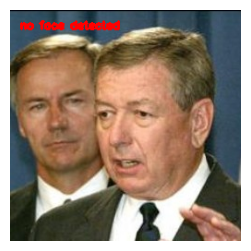

[ 66  51 167 193]
[100 113 146 106 132 140 112 164 146 158]


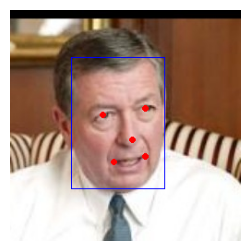

[ 71  56 175 193]
[100 109 149 111 124 139 104 161 141 163]


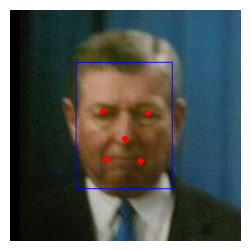

KeyboardInterrupt: 

In [3]:
# Input PNG image path
# image_path = "intra-sim/Alejandro_Toledo_/4.png"

import glob

results = {}
not_recog = []

for person in glob.glob(f'intra-sim/*'):
  images = glob.glob(f'{person}/*.png')
  for image_path in images:
    # Read image (PNG) and convert to BGR for OpenCV drawing
    try:
        pil = Image.open(image_path).convert("RGB")
        frame = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
        rets = True
    except Exception as e:
        print("Error reading image:", e)
        frame = None
        rets = False
        not_recog += [image_path]

    if not rets or frame is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
        not_recog += [image_path]

    # Use the loaded image (do not flip by default; uncomment if you want)
    image_rgb = frame.copy()  # image in BGR order for OpenCV drawing

    detection = RetinaFace.detect_faces(image_path)

    try:
      # face detection
      #print(np.array(list(RetinaFace.detect_faces(image_path)["face_1"]["facial_area"])))
      #print(np.array(list(detector.detect_faces(image_rgb)[0]["keypoints"].values())).flatten())
      bbs, lmarks = np.array(detection["face_1"]["facial_area"]), np.array(list(detection["face_1"]["landmarks"].values())).flatten()
    except:
      bbs, lmarks = [], []
      cv2.putText(image_rgb, 'no face detected', (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)

    # if at least one face is detected and
    ## If multiple subjects in the image, simply remove the image
    if "face_2" not in RetinaFace.detect_faces(image_path).keys():
        # process only one face (center ?) if multiple faces detected
        draw_landmarks(image_rgb, bbs, lmarks)  # draw landmarks and bbox
        angle, Xfrontal, Yfrontal = find_pose(lmarks)

        #cv2.putText(image_rgb, "Face Pose", (10, 40), font, 0.8, blue, 2)
        #cv2.putText(image_rgb, "Method 1", (10, 60), font, font_size, blue, 2)
        #cv2.putText(image_rgb, "Roll: {0:.2f} (-50 to +50)".format(find_roll(lmarks_5)), (10, 80), font, font_size, blue, 1)
        #cv2.putText(image_rgb, "Yaw: {0:.2f} (-100 to +100)".format(find_yaw(lmarks_5)), (10, 100), font, font_size, blue, 1)
        #cv2.putText(image_rgb, "Pitch: {0:.2f} (0 to 4)".format(find_pitch(lmarks_5)), (10, 120), font, font_size, blue, 1)

        #print("\nMethod 1")
        #print("Roll: {0:.2f} (-50 to +50)".format(find_roll(lmarks_5)))
        #print("Yaw: {0:.2f} (-100 to +100)".format(find_yaw(lmarks_5)))
        #print("Pitch: {0:.2f} (0 to 4)".format(find_pitch(lmarks_5)))

        #print("\nMethod 2")
        #cv2.putText(image_rgb, "Method 2", (10, 180), font, font_size, blue, 2)
        #cv2.putText(image_rgb, "Roll: {0:.2f} degrees".format(angle), (10,200), font, font_size, blue, 1)
        #cv2.putText(image_rgb, "Yaw: {0:.2f} degrees".format(Xfrontal), (10,220), font, font_size, blue, 1)
        #cv2.putText(image_rgb, "Pitch: {0:.2f} degrees".format(Yfrontal), (10,240), font, font_size, blue, 1)

        #print("Roll: {0:.2f} degrees".format(angle))
        #print("Yaw: {0:.2f} degrees".format(Xfrontal))
        #print("Pitch: {0:.2f} degrees".format(Yfrontal))

        results[image_path] = {
            "person": person.split("intra-sim/")[-1].replace("_", " "),
            "image": image_path,
            "roll_method1 (-50 to +50)": find_roll(lmarks),
            "yaw_method1 (-100 to +100)": find_yaw(lmarks),
            "pitch_method1 (0 to 4)": find_pitch(lmarks),
            "roll_method2": angle,
            "yaw_method2": Xfrontal,
            "pitch_method2": Yfrontal
        }
    else:
        cv2.putText(image_rgb, 'no face detected', (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)

    # Display inline in Jupyter (convert BGR -> RGB for correct colors)
    try:
      plt.figure(
          figsize=(5, 3)
      )
      plt.imshow(cv2.cvtColor(plot(image_rgb, bbs), cv2.COLOR_BGR2RGB))
      plt.axis('off')
      plt.show()
    except:
      plt.imshow(cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB))
      plt.axis('off')
      plt.show()

# **InsightFace**

In [ ]:
! pip install insightface
! pip install onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 8.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 78.0 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071349 sha256=3891e1de4bbb82c381faa6352ace92a2f5b16a6cc0ad0ff76cb57974f7b6e3fa
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.4 MB/s eta 0:00:00


In [22]:
import insightface, numpy as np
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image

import matplotlib.image as mpimg
data = ins_get_image('/content/intra-sim/Angelina_Jolie_/4')

# print(data)

model_packs=["buffalo_l","antelopev2","buffalo_m","buffalo_s","buffalo_sc"]
appnr=0 # try different models!

app = FaceAnalysis(name=model_packs[appnr])
app.prepare(ctx_id=0, det_size=(256, 256))

# Photos with a lot of people requires higher values!!
app1 = FaceAnalysis(name=model_packs[appnr])
app1.prepare(ctx_id=0, det_size=(640, 640))

# in case of zero faces
app0 = FaceAnalysis(name=model_packs[appnr])
app0.prepare(ctx_id=0, det_size=(64, 64))

# higher detection dimensions
app2 = FaceAnalysis(name=model_packs[appnr])
app2.prepare(ctx_id=0, det_size=(1280, 1280))

# How many faces do we get?
faces = app.get(data)

# print(faces)

if len(faces)==0:
    faces = app.get(data)

# Is it a family photo?
if len(faces)>2:
    faces1 = app1.get(data)
    # which one has the most faces?
    if len(faces1)>len(faces):
        faces=faces1

# This is computationally heavy...
#if len(faces)<4:
#    faces1 = app2.get(data)
#    # which one has the most faces?
#    if len(faces1)>len(faces):
        faces=faces1


for face in faces:
    box = np.round(face.bbox).astype(int)

# Make the face a bit bigger so that the CVL face detector handles it correctly. Is this necessary?
dx=int((box[2]-box[0])*0.30)
dy=int((box[3]-box[1])*0.30)
box[0]=box[0]-dx
box[1]=box[1]-dy
box[2]=box[2]+dx
box[3]=box[3]+dy

siz=data.shape

if box[0]<0:
    box[0]=0
if box[1]<0:
    box[1]=0
if box[3]>siz[0]:
    box[3]=siz[0]
if box[2]>siz[1]:
    box[2]=siz[1]

detected_face=(data[box[1]:box[3],box[0]:box[2]])

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (256, 256)
Applied prov

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   1,   0],
        [  0,   1,   0],
        [  0,   1,   0],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[ 26,  43,  46],
        [ 29,  45,  52],
        [ 36,  51,  60],
        ...,
        [  6,   8,   9],
        [  4,   6,   7],
        [  2,   4,   5]],

       [[ 33,  50,  53],
        [ 68,  84,  90],
        [ 96, 112, 119],
        ...,
        [  8,  11,  15],
        [  4,   7,  11],
        [  1,   5,   6]],

       [[ 66,  83,  86],
        [109, 126, 129],
        [180, 196, 202],
        ...,
        [ 16,  19,  23],
        [  9,  12,  16],
        [  4,   7,  11]]], dtype=uint8)
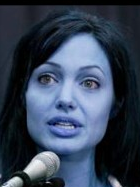

In [21]:
detected_face